# 01 - EDA e Qualidade de Fontes

Objetivo: medir o calor das fontes com uma base causal e sem inflar sistemas por multiplas aparicoes do mesmo telefone.

**Contexto:** Aqui, "calor" significa a probabilidade de entrega de uma fonte (sistema). A análise usa um join causal — um sistema só recebe crédito por um disparo se o telefone já existia naquela fonte **antes** do envio — para evitar inflar artificialmente a performance de fontes cujos telefones aparecem mais vezes. Sem esse filtro temporal, um sistema que simplesmente tem mais registros na dimensão pareceria melhor, quando na verdade pode apenas ter dados mais redundantes.

Premissas principais:
- Excluir status intermediario `processing`.
- Excluir telefones fixos com filtro case-insensitive.
- Usar entrega como metrica operacional: `delivered` ou `read`.
- Usar leitura como metrica de negócio e diagnóstico.
- Deduplicar aparicoes para uma linha por `(telefone_numero, id_sistema)`.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportion_confint

import utils as u

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print('Imports OK')


Imports OK


## 1. Carregamento e filtros

Esta etapa aplica as regras de limpeza antes de qualquer join ou ranking.


In [2]:
df_disparo_raw, df_telefone_raw = u.carregar_dados()

df_disparo = u.filtrar_status_invalidos(df_disparo_raw)
df_telefone = u.filtrar_telefones_fixos(df_telefone_raw)

print('Disparos raw:', df_disparo_raw.shape)
print('Disparos validos:', df_disparo.shape)
print('Telefones raw:', df_telefone_raw.shape)
print('Telefones validos:', df_telefone.shape)
print('\nStatus validos:')
print(df_disparo['status_disparo'].value_counts(dropna=False))
print('\nTipos de telefone apos filtro:')
print(df_telefone['telefone_tipo'].value_counts(dropna=False))


Filtrando status intermediários: 392,921 -> 389,761 (-3,160)
Filtrando telefones fixos: 283,289 -> 283,281 (-8)
Disparos raw: (392921, 16)
Disparos validos: (389761, 16)
Telefones raw: (283289, 11)
Telefones validos: (283281, 12)

Status validos:
status_disparo
read         271566
delivered     85405
failed        27257
sent           5533
Name: count, dtype: int64[pyarrow]

Tipos de telefone apos filtro:
telefone_tipo
CELULAR    283281
Name: count, dtype: int64


## 2. Aparicoes: brutas, por fonte e por CPF

A visao por fonte evita que um telefone com muitas aparicoes no mesmo sistema conte varias vezes no ranking da fonte.


In [3]:
df_aparicoes_brutas = u.explodir_aparicoes(df_telefone)
df_aparicoes_fonte = u.preparar_aparicoes_por_fonte(df_aparicoes_brutas)
df_telefone_cpf = u.preparar_telefone_cpf(df_aparicoes_brutas)

resumo_aparicoes = pd.DataFrame({
    'visao': ['bruta', 'por_fonte', 'telefone_cpf'],
    'linhas': [len(df_aparicoes_brutas), len(df_aparicoes_fonte), len(df_telefone_cpf)],
    'telefones': [df_aparicoes_brutas['telefone_numero'].nunique(), df_aparicoes_fonte['telefone_numero'].nunique(), df_telefone_cpf['telefone_numero'].nunique()],
})
display(resumo_aparicoes)
print('Reducao de linhas bruta -> por_fonte:', f"{1 - len(df_aparicoes_fonte) / len(df_aparicoes_brutas):.2%}")


Telefones únicos: 283,281
Aparições brutas: 1,522,742
Sistemas únicos: 6
Aparições por fonte deduplicadas: 669,522
Pares telefone-CPF candidatos: 1,246,889


,visao,linhas,telefones
0,bruta,1522742,283281
1,por_fonte,669522,283281
2,telefone_cpf,1246889,283281


Reducao de linhas bruta -> por_fonte: 56.03%


## 3. Join causal disparo x sistema

Para o ranking, uma fonte so recebe credito se o telefone ja existia naquela fonte antes do envio.


In [4]:
df_disparo_sistema = u.join_disparo_sistema(df_disparo, df_aparicoes_fonte, causal=True)

colunas_preview = [
    'id_disparo', 'cpf', 'contato_telefone', 'id_sistema',
    'status_disparo', 'envio_datahora', 'registro_data_atualizacao'
]
display(df_disparo_sistema[colunas_preview].head(10))


Disparos com match: 329,168 / 389,761
Total de linhas após join: 634,309
Multiplicidade média: 1.93x


,id_disparo,cpf,contato_telefone,id_sistema,status_disparo,envio_datahora,registro_data_atualizacao
0,-9223351916581235936,5.390755e+18,4064757259083255873,-4704067261970591609,read,2025-11-14 08:17:36,2025-06-20
1,-9223351916581235936,5.390755e+18,4064757259083255873,1257277410380486863,read,2025-11-14 08:17:36,2025-11-01
2,-9223351916581235936,5.390755e+18,4064757259083255873,3094574413675758272,read,2025-11-14 08:17:36,2025-02-05
3,-9223347553164632852,5.727545e+18,-5404120253297123491,-4704067261970591609,read,2025-12-12 08:04:01,2025-09-17
4,-9223347553164632852,5.727545e+18,-5404120253297123491,1257277410380486863,read,2025-12-12 08:04:01,2021-01-03
5,-9223331842594794498,2.813023e+18,2524702099694199688,3094574413675758272,delivered,2026-02-24 08:31:05,2025-10-02
6,-9223306595261143748,8.905632e+18,-19350203587627911,-4704067261970591609,read,2025-11-12 08:21:04,2025-06-18
7,-9223245723759412697,1.818394e+18,7546684854071138548,-4704067261970591609,read,2026-02-21 08:27:56,2025-10-31
8,-9223245723759412697,1.818394e+18,7546684854071138548,3094574413675758272,read,2026-02-21 08:27:56,2025-07-01
9,-9223238564413701114,7.631925e+18,-7625465242868783196,-4704067261970591609,delivered,2025-12-14 10:50:11,2025-07-20


## 4. Ranking de sistemas por entrega

O ranking principal usa limite inferior beta-binomial empirico para penalizar baixo volume e encolher fontes pequenas para a media global. O Wilson lower bound fica como diagnostico complementar.


,id_sistema,total_disparos,sucessos_entrega,taxa_entrega,taxa_leitura,taxa_falha,eb_lower_entrega,posterior_mean_entrega,wilson_lower_entrega,score_sistema
0,-4704067261970591609,195363.0,193982.0,0.992931,0.777450,0.002570,0.992526,0.992903,0.992550,1.000000
1,-2757366171786647144,6796.0,6560.0,0.965274,0.686580,0.023690,0.960862,0.965276,0.960651,0.306525
2,3094574413675758272,242123.0,231485.0,0.956064,0.743424,0.032327,0.955252,0.956071,0.955240,0.183659
3,4458959843028638627,19694.0,18760.0,0.952574,0.718290,0.027623,0.949710,0.952703,0.949517,0.062297
4,-133612832286195827,20434.0,19448.0,0.951747,0.737741,0.035921,0.948918,0.951879,0.948723,0.044935
5,1257277410380486863,149899.0,142100.0,0.947972,0.711799,0.040234,0.946866,0.947995,0.946836,0.000000


metodo_atribuicao,fonte_mais_recente,fracionario,full
id_sistema,,,
-133612832286195827,0.000000,0.000000,0.044935
-2757366171786647144,0.692905,0.401034,0.306525
-4704067261970591609,1.000000,1.000000,1.000000
1257277410380486863,0.357816,0.009613,0.000000
3094574413675758272,0.681209,0.212414,0.183659
4458959843028638627,0.322616,0.134777,0.062297


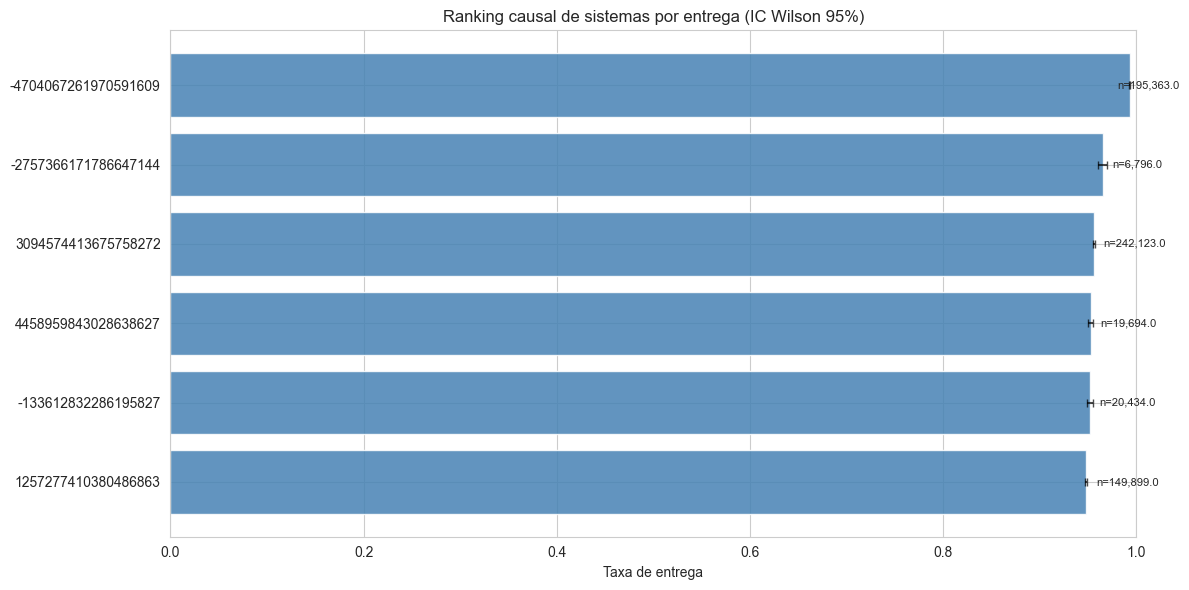

In [5]:
metricas_sistema = u.calcular_metricas_sistema(df_disparo_sistema)
metricas_sistema = u.calcular_score_sistema(metricas_sistema)

cols = [
    'id_sistema', 'total_disparos', 'sucessos_entrega', 'taxa_entrega',
    'taxa_leitura', 'taxa_falha', 'eb_lower_entrega', 'posterior_mean_entrega',
    'wilson_lower_entrega', 'score_sistema'
]
display(metricas_sistema[cols])

rankings_sensibilidade = []
for metodo_atribuicao in ['full', 'fracionario', 'fonte_mais_recente']:
    metricas_tmp = u.calcular_score_sistema(
        u.calcular_metricas_sistema(df_disparo_sistema, metodo_atribuicao=metodo_atribuicao),
        metodo_ranking='empirical_bayes'
    )
    rankings_sensibilidade.append(metricas_tmp.assign(metodo_atribuicao=metodo_atribuicao))
rankings_sensibilidade = pd.concat(rankings_sensibilidade, ignore_index=True)
display(rankings_sensibilidade.pivot_table(index='id_sistema', columns='metodo_atribuicao', values='score_sistema'))

top = metricas_sistema.head(15).copy()
top[['ci_low', 'ci_high']] = top.apply(
    lambda row: pd.Series(proportion_confint(row['sucessos_entrega'], row['total_disparos'], alpha=0.05, method='wilson')),
    axis=1,
)

fig, ax = plt.subplots(figsize=(12, 6))
y_pos = np.arange(len(top))
ax.barh(y_pos, top['taxa_entrega'], color='steelblue', alpha=0.85)
ax.errorbar(
    top['taxa_entrega'], y_pos,
    xerr=[top['taxa_entrega'] - top['ci_low'], top['ci_high'] - top['taxa_entrega']],
    fmt='none', color='black', capsize=3, alpha=0.7,
)
ax.set_yticks(y_pos)
ax.set_yticklabels(top['id_sistema'])
ax.invert_yaxis()
ax.set_xlabel('Taxa de entrega')
ax.set_title('Ranking causal de sistemas por entrega (IC Wilson 95%)')
ax.set_xlim(0, 1)
for i, (_, row) in enumerate(top.iterrows()):
    ax.text(min(row['taxa_entrega'] + 0.01, 0.98), i, f"n={row['total_disparos']:,}", va='center', fontsize=8)
plt.tight_layout()
plt.show()


## 5. Decaimento temporal

Avaliamos se a idade do dado reduz a chance de entrega.


,faixa_atualizacao,total,read,delivered,failed,sucessos_entrega,taxa_entrega,taxa_leitura
0,<30d,7230,5508,1597,72,7105,0.982711,0.761826
1,30-90d,28430,21428,6289,493,27717,0.974921,0.753711
2,90-180d,216459,165873,46485,2629,212358,0.981054,0.766302
3,180d-1a,96348,69039,22179,3494,91218,0.946756,0.716559
4,1-2a,86415,61461,19892,3838,81353,0.941422,0.711231
5,>2a,74397,52019,17415,4194,69434,0.933290,0.699208


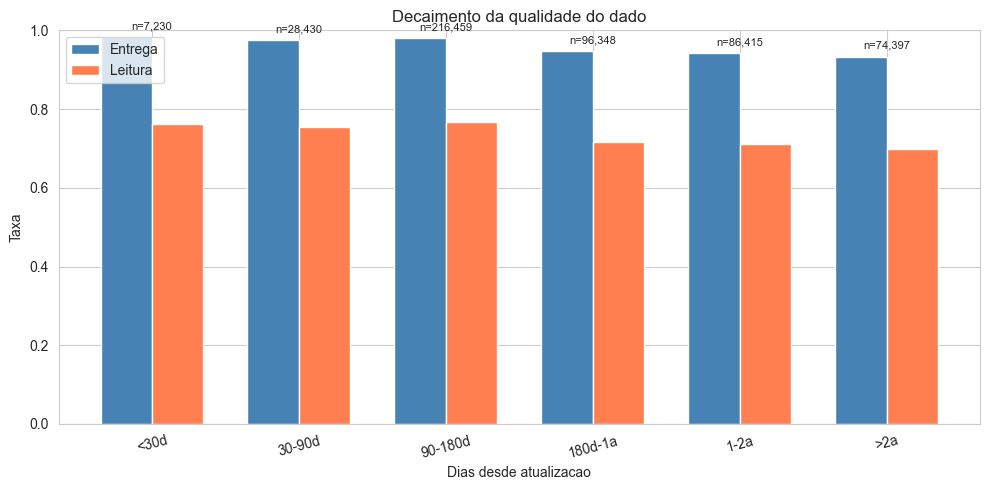

Chi-square: 5426.53
p-valor: 0.00e+00


In [6]:
decaimento = u.calcular_decaimento_temporal(df_disparo_sistema)
display(decaimento)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(decaimento))
width = 0.35
ax.bar(x - width/2, decaimento['taxa_entrega'], width, label='Entrega', color='steelblue')
ax.bar(x + width/2, decaimento['taxa_leitura'], width, label='Leitura', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(decaimento['faixa_atualizacao'], rotation=15)
ax.set_ylim(0, 1)
ax.set_ylabel('Taxa')
ax.set_xlabel('Dias desde atualizacao')
ax.set_title('Decaimento da qualidade do dado')
ax.legend()
for i, row in decaimento.iterrows():
    if pd.notna(row['total']):
        ax.text(i, max(row['taxa_entrega'], row['taxa_leitura']) + 0.02, f"n={int(row['total']):,}", ha='center', fontsize=8)
plt.tight_layout()
plt.show()

contingencia = decaimento[['sucessos_entrega']].copy()
contingencia['nao_entrega'] = decaimento['total'] - decaimento['sucessos_entrega']
contingencia = contingencia.dropna()
if len(contingencia) > 1:
    chi2, p_valor, dof, esperado = stats.chi2_contingency(contingencia.values)
    print(f'Chi-square: {chi2:.2f}')
    print(f'p-valor: {p_valor:.2e}')
else:
    print('Sem faixas suficientes para teste chi-square.')


### 6.0 Por que os testes de viés de seleção importam

Antes de aceitar o ranking de fontes, três testes de viés de seleção são necessários para verificar se o ranking reflete qualidade real ou apenas artefatos de volume ou atribuição:

1. **Correlação volume vs. taxa:** Se fontes com mais disparos têm taxas artificialmente infladas (pelo peso amostral), o ranking pode ser espúrio. O teste de Pearson com log-volume ajuda a descartar essa hipótese.
2. **First-touch vs. full attribution:** Se o ranking muda significativamente quando atribuímos crédito apenas à fonte mais recente (first-touch) em vez de todas as fontes causais, isso indica que a escolha do método de atribuição importa para a conclusão — e que devemos ser cautelosos com qualquer ranking único.
3. **Vitórias intra-CPF:** Comparando telefones do mesmo CPF, eliminamos vieses de CPF (p.ex., CPFs com telefones melhores tendendo a certo sistema). A taxa de vitória intra-CPF mostra se uma fonte ganha consistentemente quando compete com outras para o mesmo cidadão.

## 6. Sinais de vies de selecao

Comparamos volume, first-touch e vitorias intra-CPF para separar qualidade real de pre-selecao historica.


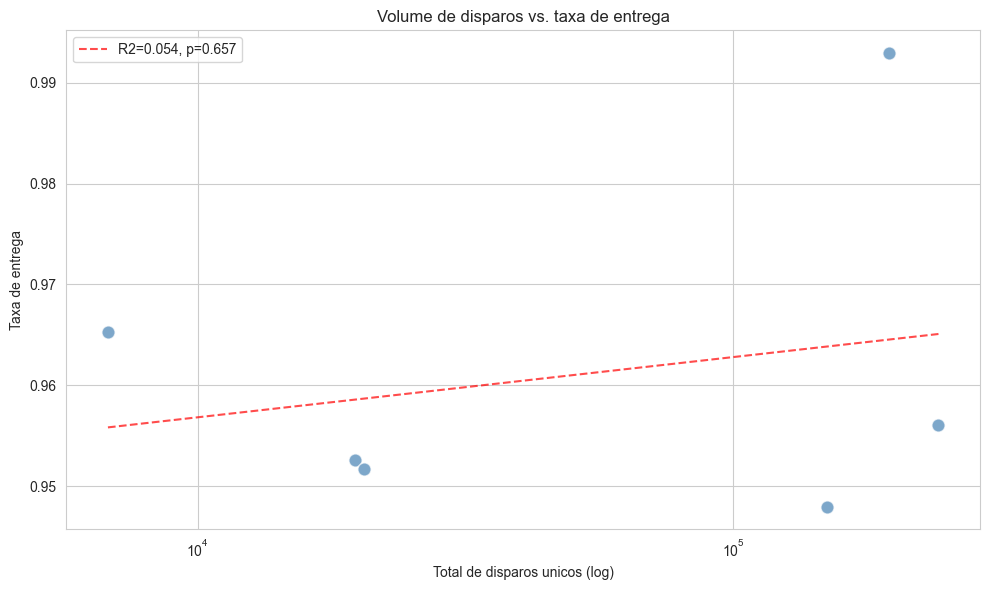

Correlacao Pearson (log volume vs taxa): R=0.233, p=0.657


In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(metricas_sistema['total_disparos'], metricas_sistema['taxa_entrega'], s=90, alpha=0.7, color='steelblue', edgecolors='white')
log_vol = np.log10(metricas_sistema['total_disparos'])
slope, intercept, r_value, p_value, std_err = stats.linregress(log_vol, metricas_sistema['taxa_entrega'])
x_fit = np.linspace(metricas_sistema['total_disparos'].min(), metricas_sistema['total_disparos'].max(), 100)
y_fit = slope * np.log10(x_fit) + intercept
ax.plot(x_fit, y_fit, 'r--', alpha=0.7, label=f'R2={r_value**2:.3f}, p={p_value:.3f}')
ax.set_xscale('log')
ax.set_xlabel('Total de disparos unicos (log)')
ax.set_ylabel('Taxa de entrega')
ax.set_title('Volume de disparos vs. taxa de entrega')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Correlacao Pearson (log volume vs taxa): R={r_value:.3f}, p={p_value:.3f}')


In [8]:
df_first = (
    df_disparo.sort_values('envio_datahora')
    .drop_duplicates(subset='contato_telefone', keep='first')
)
df_first_sistema = u.join_disparo_sistema(df_first, df_aparicoes_fonte, causal=True)
metricas_first = u.calcular_score_sistema(u.calcular_metricas_sistema(df_first_sistema))

comparacao_first = metricas_sistema[['id_sistema', 'eb_lower_entrega', 'taxa_entrega']].merge(
    metricas_first[['id_sistema', 'eb_lower_entrega', 'taxa_entrega']],
    on='id_sistema', how='outer', suffixes=('_geral', '_first')
)
comparacao_first['rank_geral'] = comparacao_first['eb_lower_entrega_geral'].rank(ascending=False)
comparacao_first['rank_first'] = comparacao_first['eb_lower_entrega_first'].rank(ascending=False)
comparacao_first['delta_rank'] = comparacao_first['rank_geral'] - comparacao_first['rank_first']

display(comparacao_first.sort_values('rank_first'))


Disparos com match: 240,542 / 293,342
Total de linhas após join: 448,360
Multiplicidade média: 1.86x


,id_sistema,eb_lower_entrega_geral,taxa_entrega_geral,eb_lower_entrega_first,taxa_entrega_first,rank_geral,rank_first,delta_rank
2,-4704067261970591609,0.992526,0.992931,0.996918,0.997246,1.0,1.0,0.0
1,-2757366171786647144,0.960862,0.965274,0.967945,0.972782,2.0,2.0,0.0
4,3094574413675758272,0.955252,0.956064,0.961637,0.962522,3.0,3.0,0.0
0,-133612832286195827,0.948918,0.951747,0.958271,0.961297,5.0,4.0,1.0
5,4458959843028638627,0.949710,0.952574,0.955047,0.958479,4.0,5.0,-1.0
3,1257277410380486863,0.946866,0.947972,0.953007,0.954229,6.0,6.0,0.0


In [9]:
cpf_sistema = (
    df_disparo_sistema.dropna(subset=['cpf'])
    .groupby(['cpf', 'id_sistema'])
    .agg(
        total=('id_disparo', 'nunique'),
        entregas=('status_disparo', lambda s: s.isin(u.STATUS_ENTREGA).sum()),
        leituras=('status_disparo', lambda s: (s == 'read').sum()),
    )
    .reset_index()
)
cpf_sistema['taxa_entrega'] = cpf_sistema['entregas'] / cpf_sistema['total']
cpf_multi = cpf_sistema.groupby('cpf')['id_sistema'].nunique().loc[lambda s: s >= 2].index
cpf_rank = cpf_sistema[cpf_sistema['cpf'].isin(cpf_multi)].copy()
cpf_rank['rank_no_cpf'] = cpf_rank.groupby('cpf')['taxa_entrega'].rank(ascending=False, method='first')

vitorias = cpf_rank[cpf_rank['rank_no_cpf'] == 1].groupby('id_sistema').size().reset_index(name='vitorias')
participacoes = cpf_rank.groupby('id_sistema').size().reset_index(name='participacoes')
vitorias = vitorias.merge(participacoes, on='id_sistema', how='outer').fillna(0)
vitorias['taxa_vitoria'] = np.where(vitorias['participacoes'] > 0, vitorias['vitorias'] / vitorias['participacoes'], np.nan)
vitorias = vitorias.sort_values('taxa_vitoria', ascending=False)

display(vitorias)


,id_sistema,vitorias,participacoes,taxa_vitoria
0,-133612832286195827,13312,13400,0.993433
2,-4704067261970591609,110801,121009,0.915643
1,-2757366171786647144,3396,3738,0.908507
3,1257277410380486863,23298,83411,0.279316
4,3094574413675758272,2349,135570,0.017327
5,4458959843028638627,16,12116,0.001321


## 6.1 Desempenho por Categoria de Campanha

Sistemas podem performar diferentemente conforme o tipo de campanha (saude, educacao, IPTU etc.). Esta secao verifica se o ranking causal se susta quando estratificado por `categoria_hsm`.

categoria_hsm,Autenticação,Marketing,REMOVED,Utilidade
id_sistema,,,,
-133612832286195827,93.7%,100.0%,—,95.3%
-2757366171786647144,94.9%,87.3%,71.4%,96.9%
-4704067261970591609,99.2%,91.9%,71.4%,99.3%
1257277410380486863,96.6%,89.2%,71.4%,94.7%
3094574413675758272,96.8%,100.0%,—,95.6%
4458959843028638627,93.5%,50.0%,71.4%,95.4%


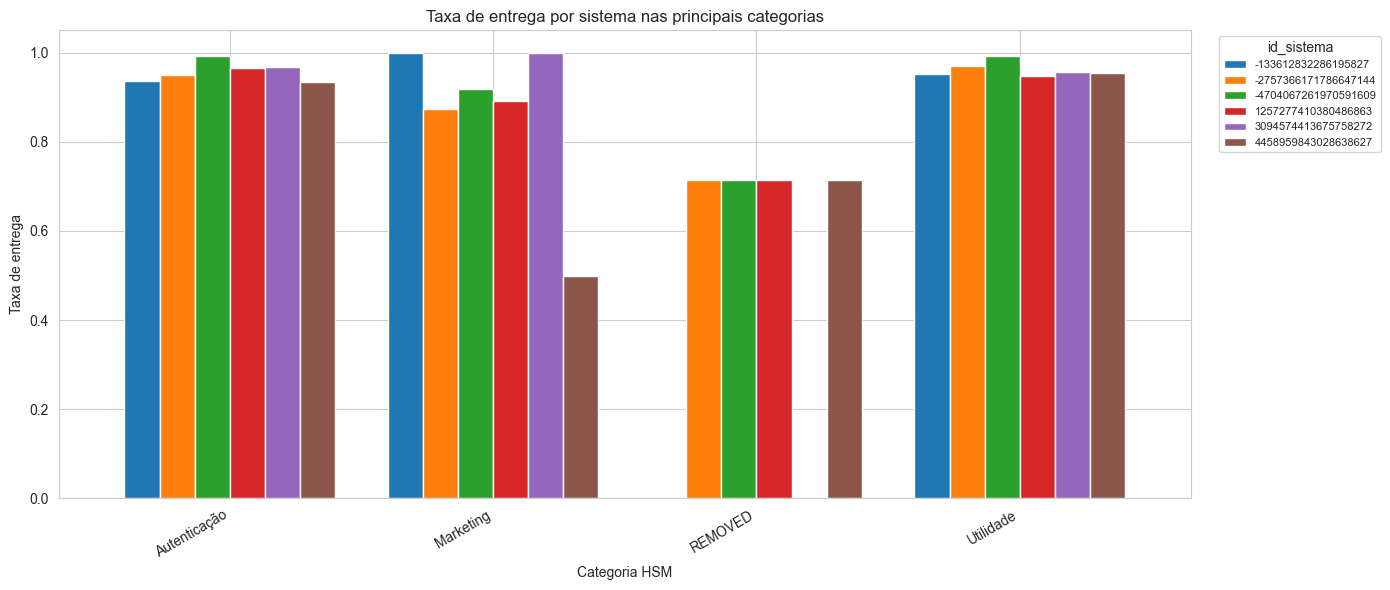

In [10]:
metricas_por_categoria = u.calcular_metricas_por_categoria(df_disparo_sistema, df_disparo)

if metricas_por_categoria is not None:
    top_sistemas = metricas_sistema.head(10)['id_sistema'].tolist()
    pivot = (
        metricas_por_categoria[metricas_por_categoria['id_sistema'].isin(top_sistemas)]
        .pivot_table(index='id_sistema', columns='categoria_hsm', values='taxa_entrega')
    )
    display(pivot.style.format('{:.1%}', na_rep='\u2014').set_caption('Taxa de entrega por sistema x categoria_hsm'))

    fig, ax = plt.subplots(figsize=(14, 6))
    pivot.T.plot(kind='bar', ax=ax, width=0.8)
    ax.set_ylabel('Taxa de entrega')
    ax.set_xlabel('Categoria HSM')
    ax.set_title('Taxa de entrega por sistema nas principais categorias')
    ax.legend(title='id_sistema', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('categoria_hsm nao disponivel para quebra estratificada.')

---
## Pontos de Atenção

- **Ranking robusto mas diferenças pequenas:** O ranking é robusto entre métodos de atribuição (full, fracionário, first-touch), mas todos os 6 sistemas têm taxas de entrega muito similares (~94-99%). A diferenciação prática entre fontes é pequena, o que limita o ganho potencial de qualquer estratégia de priorização.
- **Vitória intra-CPF assimétrica:** O sistema -4704... vence 91,6% das vezes em que compete, mas o sistema 3094... (2ª maior fonte) vence apenas 1,7% — seu volume alto pode estar inflando sua taxa agregada, já que intra-CPF seu desempenho é fraco.
- **Decaimento temporal com não-monotonicidade:** A entrega é ~98% para dados com <180d, mas cai para ~93% para dados com >2a. Porém, a relação não é estritamente monotônica: a faixa 90-180d tem taxa ligeiramente maior que 30-90d.
- **Apenas 6 sistemas:** A generalização do ranking para outros sistemas além destes 6 é desconhecida.

## 7. Artefatos da Parte 1


In [11]:
metricas_final = metricas_sistema.merge(
    metricas_first[['id_sistema', 'eb_lower_entrega', 'wilson_lower_entrega']].rename(columns={
        'eb_lower_entrega': 'eb_first_touch_entrega',
        'wilson_lower_entrega': 'wilson_first_touch_entrega',
    }),
    on='id_sistema', how='left'
).merge(
    vitorias[['id_sistema', 'taxa_vitoria']],
    on='id_sistema', how='left'
)

u.PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
artefatos = {
    'metricas_sistema': metricas_final,
    'rankings_sensibilidade': rankings_sensibilidade,
    'decaimento': decaimento,
    'metricas_first_touch': metricas_first,
    'vitorias_intra_cpf': vitorias,
}
for nome, obj in artefatos.items():
    caminho = u.PROCESSED_DIR / f'{nome}.pkl'
    with open(caminho, 'wb') as f:
        pickle.dump(obj, f)
    print(f'{nome} salvo em {caminho}')

display(metricas_final)


metricas_sistema salvo em C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\data\processed\metricas_sistema.pkl
rankings_sensibilidade salvo em C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\data\processed\rankings_sensibilidade.pkl
decaimento salvo em C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\data\processed\decaimento.pkl
metricas_first_touch salvo em C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\data\processed\metricas_first_touch.pkl
vitorias_intra_cpf salvo em C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\data\processed\vitorias_intra_cpf.pkl


,id_sistema,total_disparos,read,delivered,failed,sent,sucessos_entrega,taxa_entrega,taxa_leitura,taxa_falha,metodo_atribuicao,wilson_lower_entrega,posterior_mean_entrega,eb_lower_entrega,score_sistema_raw,score_sistema,metodo_ranking,eb_first_touch_entrega,wilson_first_touch_entrega,taxa_vitoria
0,-4704067261970591609,195363.0,151885.0,42097.0,502.0,879.0,193982.0,0.992931,0.777450,0.002570,full,0.992550,0.992903,0.992526,0.992526,1.000000,empirical_bayes,0.996918,0.996951,0.915643
1,-2757366171786647144,6796.0,4666.0,1894.0,161.0,75.0,6560.0,0.965274,0.686580,0.023690,full,0.960651,0.965276,0.960862,0.960862,0.306525,empirical_bayes,0.967945,0.967710,0.908507
2,3094574413675758272,242123.0,180000.0,51485.0,7827.0,2811.0,231485.0,0.956064,0.743424,0.032327,full,0.955240,0.956071,0.955252,0.955252,0.183659,empirical_bayes,0.961637,0.961622,0.017327
3,4458959843028638627,19694.0,14146.0,4614.0,544.0,390.0,18760.0,0.952574,0.718290,0.027623,full,0.949517,0.952703,0.949710,0.949710,0.062297,empirical_bayes,0.955047,0.954720,0.001321
4,-133612832286195827,20434.0,15075.0,4373.0,734.0,252.0,19448.0,0.951747,0.737741,0.035921,full,0.948723,0.951879,0.948918,0.948918,0.044935,empirical_bayes,0.958271,0.958051,0.993433
5,1257277410380486863,149899.0,106698.0,35402.0,6031.0,1768.0,142100.0,0.947972,0.711799,0.040234,full,0.946836,0.947995,0.946866,0.946866,0.000000,empirical_bayes,0.953007,0.952966,0.279316
